# Runbook Ingestion Pipeline

Walks through the ingestion pipeline for RunbookRAG: turning a runbook markdown file into vectors ready for retrieval.

1. **Chunk** - `app.ingestion.chunking` splits each runbook on its heading structure into embeddable pieces
2. **Embed** - `app.ingestion.embedder` turns each chunk into a dense vector using a local sentence-transformers model (no API key or network call needed for inference)

A third step - storing chunks + vectors in the pgvector-backed Postgres database - isn't implemented yet, so this notebook stops after embedding.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.ingestion.chunking import Chunk, chunk_file
from app.ingestion.embedder import embed_chunks

RUNBOOKS_DIR = PROJECT_ROOT / "data" / "runbooks" / "gitlab"
paths = sorted(RUNBOOKS_DIR.glob("*.md"))
paths

[PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/gitaly-down.md'),
 PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/patroni-postgres-performance-degradation.md'),
 PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/pgbouncer-saturation.md'),
 PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/redis-troubleshooting.md'),
 PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/sidekiq-error-rate-high.md'),
 PosixPath('/Users/chrischen/dev/runbookrag/data/runbooks/gitlab/vault-troubleshooting.md')]

## Step 1: Chunk the runbooks

`chunk_file()` splits each markdown runbook on its heading structure rather than fixed-size windows. Each chunk is prefixed with a heading breadcrumb (e.g. `Troubleshooting > What is causing Redis to slowdown? > slowlog`) so it stays meaningful once embedded in isolation, and oversized sections are further split with `chunk_overlap` characters of shared context - all while never cutting inside a fenced code block.

In [2]:
chunks_by_file = {path.name: chunk_file(path) for path in paths}

for name, chunks in chunks_by_file.items():
    sizes = [len(c.text) for c in chunks]
    print(f"{name:55s} {len(chunks):3d} chunks   {min(sizes):5d}-{max(sizes):5d} chars")

gitaly-down.md                                            5 chunks      88- 1223 chars
patroni-postgres-performance-degradation.md              13 chunks     204- 3497 chars
pgbouncer-saturation.md                                   6 chunks     255- 2618 chars
redis-troubleshooting.md                                 62 chunks      74- 3214 chars
sidekiq-error-rate-high.md                                5 chunks      81- 1532 chars
vault-troubleshooting.md                                 17 chunks     165- 1997 chars


### Inspect the chunks

A closer look at what chunking actually produced: size distribution, a sample of chunks with their breadcrumbs, and a real example of overlap between two adjacent pieces of a split section.

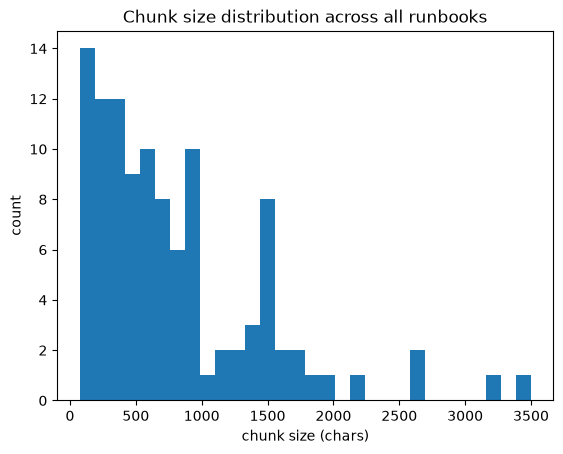

In [3]:
all_sizes = [len(c.text) for chunks in chunks_by_file.values() for c in chunks]

plt.hist(all_sizes, bins=30)
plt.xlabel("chunk size (chars)")
plt.ylabel("count")
plt.title("Chunk size distribution across all runbooks")
plt.show()

In [4]:
sample_name = "redis-troubleshooting.md"

for chunk in chunks_by_file[sample_name][:5]:
    print(f"--- [{' > '.join(chunk.heading_path)}]  ({len(chunk.text)} chars)")
    print(chunk.text[:300])
    print()

--- [Troubleshooting > Is redis running? > Grafana]  (965 chars)
Troubleshooting > Is redis running? > Grafana

Grafana dashboards:

- [redis](https://dashboards.gitlab.net/d/redis-main/redis-overview?orgId=1&from=now-6h&to=now)
- [redis-cache](https://dashboards.gitlab.net/d/redis-cache-main/redis-cache-overview?orgId=1&from=now-6h&to=now)
- [redis-sidekiq](http

--- [Troubleshooting > Is redis running? > Prometheus/Thanos]  (144 chars)
Troubleshooting > Is redis running? > Prometheus/Thanos

<https://thanos.gitlab.net/graph?g0.range_input=1w&g0.expr=redis_up%20%3C%201&g0.tab=0>

--- [Troubleshooting > Is redis running? > directly on a redis host]  (325 chars)
Troubleshooting > Is redis running? > directly on a redis host

- is redis up?
  - `gitlab-ctl status`
- can we dial redis?
  - `telnet localhost 6379`
- can we talk to redis via `redis-cli`?

```
REDISCLI_AUTH=$(sudo grep ^masterauth /var/opt/gitlab/redis/redis.conf|cut -d\" -f2)
/opt/gitlab/embedd

--- [Troubleshooting > How t

## Overlap between adjacent chunks

When a section is too large for `max_chars`, it gets split into multiple pieces with `chunk_overlap` characters of trailing context carried from one piece into the next. Find a real example and show the boundary.

In [5]:
import itertools


def strip_breadcrumb(text: str, heading_path: list[str]) -> str:
    prefix = f"{' > '.join(heading_path)}\n\n"
    return text.removeprefix(prefix)


def shared_lines(a, b) -> list[str]:
    a_lines = strip_breadcrumb(a.text, a.heading_path).splitlines()
    b_lines = strip_breadcrumb(b.text, b.heading_path).splitlines()
    for k in range(min(len(a_lines), len(b_lines)), 0, -1):
        if a_lines[-k:] == b_lines[:k]:
            return a_lines[-k:]
    return []


def find_visible_overlap_example():
    candidates = []
    for name, chunks in chunks_by_file.items():
        for a, b in itertools.pairwise(chunks):
            if a.heading_path == b.heading_path and b.chunk_index == a.chunk_index + 1:
                candidates.append((len(shared_lines(a, b)), name, a, b))
    candidates.sort(key=lambda c: c[0], reverse=True)
    return candidates[0] if candidates else None


overlap_line_count, name, a, b = find_visible_overlap_example()

print(f"File: {name}")
print(f"Section: {' > '.join(a.heading_path)}")
print(f"chunk {a.chunk_index} is {len(a.text)} chars, chunk {b.chunk_index} is {len(b.text)} chars")
print(f"carried-over overlap: {overlap_line_count} line(s)\n")

print(f"--- end of chunk {a.chunk_index} ---")
print(a.text[-250:])
print(f"\n--- start of chunk {b.chunk_index} ---")
print(b.text[:250])

File: redis-troubleshooting.md
Section: Troubleshooting > Failover and Recovery procedures > Switch Master manually > How to manually switch primaries
chunk 53 is 1541 chars, chunk 54 is 583 chars
carried-over overlap: 5 line(s)

--- end of chunk 53 ---
4) "2"
   35) "quorum"
   36) "2"
   37) "failover-timeout"
   38) "60000"
   39) "parallel-syncs"
   40) "1"
```

1. Failover the master to one of the replicas:

```shell
/opt/gitlab/embedded/bin/redis-cli -p 26379 SENTINEL failover CLUSTER_NAME
```

--- start of chunk 54 ---
Troubleshooting > Failover and Recovery procedures > Switch Master manually > How to manually switch primaries

1. Failover the master to one of the replicas:

```shell
/opt/gitlab/embedded/bin/redis-cli -p 26379 SENTINEL failover CLUSTER_NAME
```

C


## Step 2: Generate embeddings

`embed_chunks()` batches chunk text through a local sentence-transformers model (`all-MiniLM-L6-v2`, 384 dimensions). Because the model runs locally, there's no API key and no per-call cost - the only network access needed is a one-time download of the model weights from Hugging Face Hub, cached locally after that.

In [6]:
all_chunks = [chunk for chunks in chunks_by_file.values() for chunk in chunks]
embedded = embed_chunks(all_chunks)

print(f"Embedded {len(embedded)} chunks")
print(f"Model: {embedded[0].model}")
print(f"Vector dimension: {len(embedded[0].embedding)}")
print(f"First 8 values of the first vector: {embedded[0].embedding[:8]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedded 108 chunks
Model: all-MiniLM-L6-v2
Vector dimension: 384
First 8 values of the first vector: [0.01610466279089451, -0.005673309322446585, 0.0359012633562088, 0.01430059690028429, -0.009156152606010437, -0.1779085099697113, 0.04042595624923706, -0.013023377396166325]


### Sanity check: do the embeddings capture meaning?

Two chunks describing the same kind of problem should land closer together in vector space than two chunks about unrelated topics, even without shared keywords.

In [7]:
import math


def cosine_similarity(a: list[float], b: list[float]) -> float:
    dot = sum(x * y for x, y in zip(a, b, strict=True))
    norm_a = math.sqrt(sum(x * x for x in a))
    norm_b = math.sqrt(sum(y * y for y in b))
    return dot / (norm_a * norm_b)


demo_chunks = [
    Chunk(text="Redis is down and not responding to PING", heading_path=[], source="demo", chunk_index=0),
    Chunk(text="The Redis server is unreachable and failing health checks", heading_path=[], source="demo", chunk_index=1),
    Chunk(text="Bake sourdough bread with a long cold proof", heading_path=[], source="demo", chunk_index=2),
]
demo_embedded = embed_chunks(demo_chunks)
redis_a, redis_b, unrelated = (item.embedding for item in demo_embedded)

print(f"similarity(redis outage, redis outage):    {cosine_similarity(redis_a, redis_b):.3f}")
print(f"similarity(redis outage, unrelated bread): {cosine_similarity(redis_a, unrelated):.3f}")

similarity(redis outage, redis outage):    0.668
similarity(redis outage, unrelated bread): 0.053


## Step 3: Store in pgvector

`store_chunks()` upserts each embedded chunk into Postgres by a deterministic id (a hash of `source:chunk_index`), so re-running this cell won't create duplicates - it just overwrites the same rows. Requires a running database (`docker compose up -d db`).

In [8]:
from app.ingestion.store import (
    connect,
    count,
    count_by_source,
    ensure_schema,
    query_similar,
    store_chunks,
)

conn = connect()
ensure_schema(conn)

store_chunks(conn, embedded)

print(f"Total chunks in the table: {count(conn)}")
sample_path = str(RUNBOOKS_DIR / sample_name)
print(f"Chunks from {sample_name}: {count_by_source(conn, sample_path)}")

Total chunks in the table: 108
Chunks from redis-troubleshooting.md: 62


### Verify: query the stored chunks

Embed a natural-language question and retrieve the closest stored chunks by cosine distance - a preview of what the retrieval step will do.

In [9]:
query_text = "redis server won't respond to ping"
query_chunk = Chunk(text=query_text, heading_path=[], source="query", chunk_index=0)
query_embedding = embed_chunks([query_chunk])[0].embedding

results = query_similar(conn, query_embedding, k=3)
for _id, source, chunk_index, heading_path, text, model, distance in results:
    print(f"[{distance:.3f}] {' > '.join(heading_path)}  ({Path(source).name}, chunk {chunk_index})")
    print(text[:150])
    print()

[0.416] Troubleshooting > Failover and Recovery procedures > Replication issues > Redis Sentinel > Get Redis master  (redis-troubleshooting.md, chunk 45)
Troubleshooting > Failover and Recovery procedures > Replication issues > Redis Sentinel > Get Redis master

Once you have the IP of a sentinel, use `

[0.432] Troubleshooting > What is causing Redis to slowdown? > redis-cli sub-commands > --latency-history  (redis-troubleshooting.md, chunk 14)
Troubleshooting > What is causing Redis to slowdown? > redis-cli sub-commands > --latency-history

`redis-cli` has a useful command-line argument `--l

[0.432] Troubleshooting > What is causing Redis to slowdown? > Redis latency monitoring framework > LATENCY DOCTOR  (redis-troubleshooting.md, chunk 12)
Troubleshooting > What is causing Redis to slowdown? > Redis latency monitoring framework > LATENCY DOCTOR

```shell
> CONFIG SET latency-monitor-thre

